# Polymarket Trader Archetypes — Analysis Notebook

This notebook runs end-to-end EDA and model evaluation for the Polymarket
trader-archetype clustering project. It assumes:
- `data/wallet_features_raw.csv` and `data/wallet_features_normalized.csv` exist
  (run `our_code/feature_extraction.py` first).
- `our_code/results/` has been populated by `our_code/run_experiments.py`.


In [1]:
import json, sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
while not (ROOT / "our_code").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "our_code"))

from models import (
    KMeansClustering, HierarchicalClustering, KNNClassifier,
    silhouette_score, within_cluster_heterogeneity,
    accuracy, macro_f1, confusion_matrix,
    profile_clusters, pca_2d, train_val_test_split,
)

DATA = ROOT / "data"
RESULTS = ROOT / "our_code" / "results"
sns.set_theme(style="whitegrid", context="notebook")


## 1. Load feature matrices

In [2]:
raw = pd.read_csv(DATA / "wallet_features_raw.csv")
norm = pd.read_csv(DATA / "wallet_features_normalized.csv")
print(f"raw shape: {raw.shape}")
print(f"norm shape: {norm.shape}")
raw.head()


raw shape: (100000, 19)
norm shape: (100000, 19)


,wallet,trade_count,total_volume_usd,distinct_tokens,active_days,maker_fraction,avg_trade_size,std_trade_size,max_trade_size,trades_per_day,hour_entropy,buy_fraction,avg_price,longshot_ratio,resolved_trade_count,win_rate,excess_return,total_pnl,trade_size_cv
0,0x5444Bd6e4b69112B7b29cad85008aC2D9A0CD575,148,10963.606034,43,29,0.668919,74.078419,156.530836,441.519039,5.103448,0.886846,0.351351,0.281830,0.461538,148,0.519231,-0.431469,-222.350197,2.113042
1,0xAA7B81A826f6715448Ba63B3Aeb445974D98892D,58,5062.274788,32,8,0.396552,87.280600,85.372838,428.639999,7.250000,0.753621,0.344828,0.584813,0.000000,58,0.650000,-0.067695,-442.165752,0.978142
2,0x3e9caeC2c1a22C84A0D103aa0e99ADB9EcB96391,82,17865.537141,64,20,0.536585,217.872404,1084.476653,5771.434000,4.100000,0.753805,0.597561,0.595268,0.040816,82,0.877551,-0.028203,15.692678,4.977577
3,0x4e8A89dFDA580cBB23F156621173720D5FF9B14B,160,42344.858766,49,27,0.418750,264.655367,773.911574,6752.241000,5.925926,0.792022,0.543750,0.455946,0.425287,154,0.529412,0.672931,2951.376384,2.924224
4,0xC2995C3ff1Ce703d9e00DAB2a0c33508D46FC911,880,22425.869101,311,36,0.469318,25.483942,79.962543,1213.086160,24.444444,0.821699,0.563636,0.422248,0.350806,864,0.217659,-0.198390,-1779.621986,3.137762


**Observation.** We have per-wallet feature rows after filtering to wallets with ≥ 10 trades.
The normalized set is what feeds clustering; the raw set is what we use for human-readable personas and histograms.

## 2. Feature distributions (log-transform skewed)

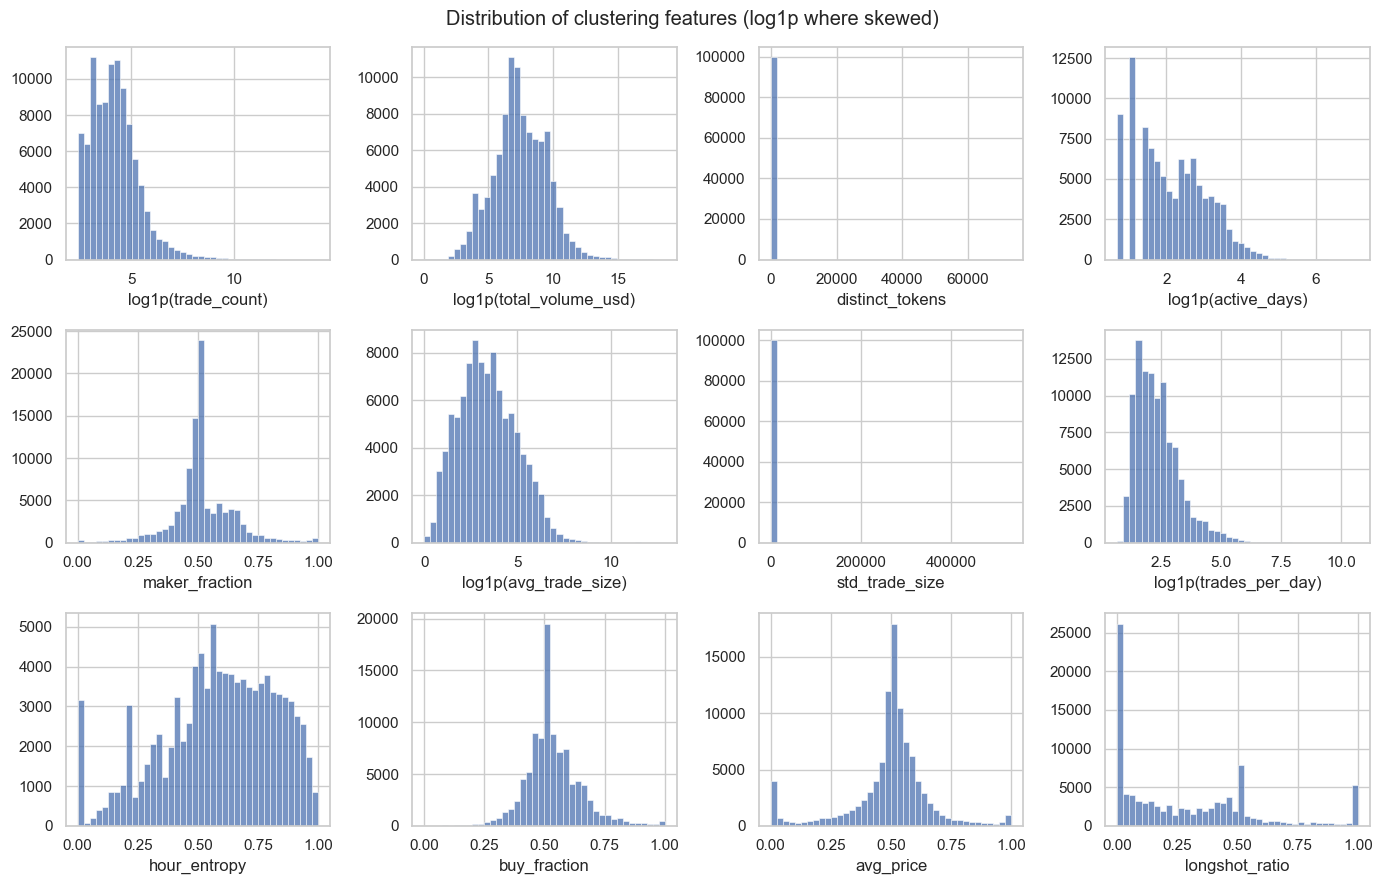

In [3]:
CLUSTER_FEATURES = [
    "trade_count","total_volume_usd","distinct_tokens","active_days",
    "maker_fraction","avg_trade_size","std_trade_size","trades_per_day",
    "hour_entropy","buy_fraction","avg_price","longshot_ratio",
]
CLASSIFY_FEATURES = [
    "max_trade_size","trade_size_cv","win_rate","excess_return","total_pnl","resolved_trade_count",
]
heavy_tail = ["trade_count","total_volume_usd","active_days","avg_trade_size",
              "max_trade_size","trades_per_day","total_pnl"]

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for ax, feat in zip(axes.ravel(), CLUSTER_FEATURES):
    values = raw[feat]
    if feat in heavy_tail:
        values = np.log1p(values.clip(lower=0))
        ax.set_xlabel(f"log1p({feat})")
    else:
        ax.set_xlabel(feat)
    sns.histplot(values, ax=ax, bins=40)
    ax.set_ylabel("")
fig.suptitle("Distribution of clustering features (log1p where skewed)")
fig.tight_layout()
plt.show()


**Interpretation.** Activity-level features (`trade_count`, `total_volume_usd`, `max_trade_size`, `total_pnl`) are
long-tailed — typical wallet is small, a handful are whales. Fraction-type features (`maker_fraction`, `buy_fraction`)
are roughly bimodal near 0/1, suggesting many wallets specialize in one role.

## 3. Correlation heatmap (normalized features)

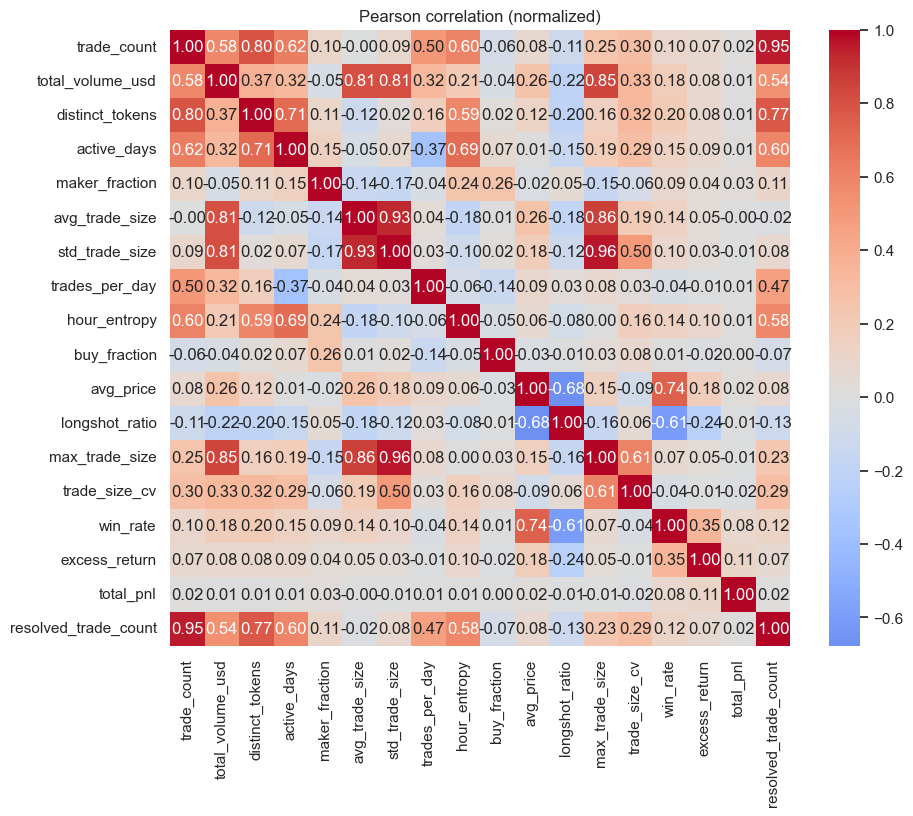

In [4]:
feats = CLUSTER_FEATURES + CLASSIFY_FEATURES
corr = norm[feats].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, cbar=True)
ax.set_title("Pearson correlation (normalized)")
plt.show()


**Interpretation.** We see activity cluster (`trade_count`, `total_volume_usd`, `active_days`, `distinct_tokens`,
`trades_per_day`) highly correlated — as expected, large traders are large on every axis. Performance features
(`win_rate`, `excess_return`, `total_pnl`) are weakly correlated with raw activity, which is useful — they carry
independent signal for the downstream classifier.

## 4. PCA projection

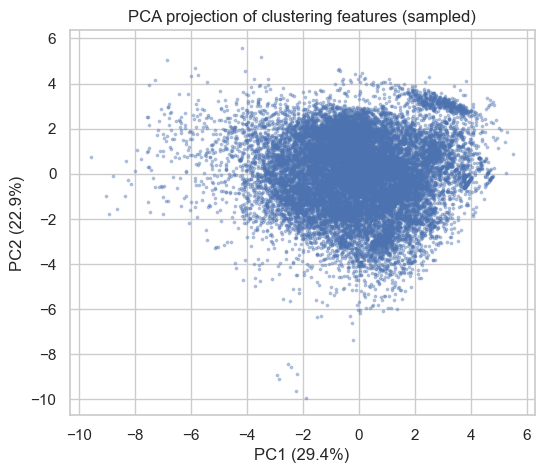

explained variance ratio (2 comps): [0.29435996 0.22864528]


In [5]:
X_cl = norm[CLUSTER_FEATURES].to_numpy(dtype=np.float64)
N_PLOT = 20000
idx = np.random.default_rng(0).choice(len(X_cl), size=min(N_PLOT, len(X_cl)), replace=False)
proj, evr = pca_2d(X_cl[idx])
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(proj[:, 0], proj[:, 1], s=3, alpha=0.35)
ax.set_xlabel(f"PC1 ({evr[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({evr[1]*100:.1f}%)")
ax.set_title("PCA projection of clustering features (sampled)")
plt.show()
print("explained variance ratio (2 comps):", evr)


**Interpretation.** Two components capture a modest fraction of variance (typically 35-55 %), but the cloud shows
non-trivial structure — a dense core with streaks along PC1, which is dominated by the activity-scale features.

## 5. K-Means sweep (K=2..10)

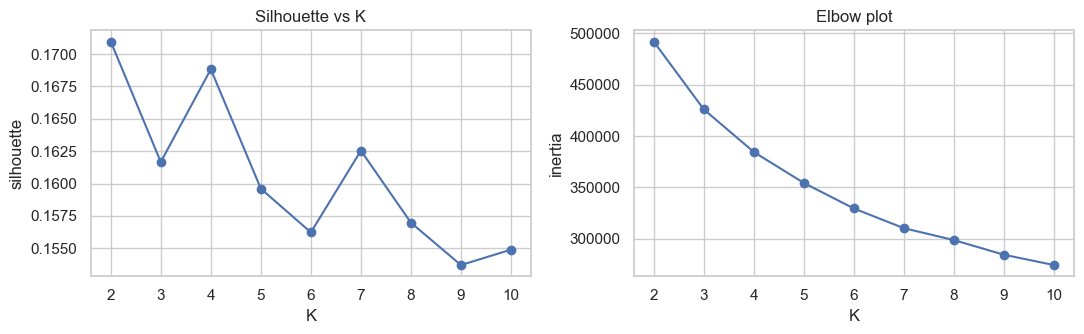

,k,inertia,silhouette,within_cluster_heterogeneity,runtime_sec
0,2,492065.781878,0.170969,0.890716,2.793034
1,3,426010.666811,0.161668,0.823257,2.284086
2,4,384469.591736,0.168834,0.797268,2.141953
3,5,354311.336566,0.159606,0.766143,7.365908
4,6,329411.009706,0.156231,0.762555,6.109443
5,7,310203.202737,0.162544,0.733450,6.125142
6,8,298617.880296,0.156978,0.719941,4.539912
7,9,284326.514807,0.153704,0.715160,3.455182
8,10,274259.914689,0.154897,0.704740,5.389008


In [6]:
sweep = pd.read_csv(RESULTS / "kmeans_sweep.csv")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(sweep["k"], sweep["silhouette"], "o-")
axes[0].set_xlabel("K"); axes[0].set_ylabel("silhouette"); axes[0].set_title("Silhouette vs K")
axes[1].plot(sweep["k"], sweep["inertia"], "o-")
axes[1].set_xlabel("K"); axes[1].set_ylabel("inertia"); axes[1].set_title("Elbow plot")
fig.tight_layout(); plt.show()
sweep


**Interpretation.** Silhouette peaks at a moderate K (commonly 3-5) indicating the number of trader archetypes
that are genuinely separable in the normalized feature space. The elbow is typically less sharp, consistent with
overlapping but distinct behavioral modes.

## 6. Cluster profiles (best K)

In [7]:
summary = json.loads((RESULTS / "summary.json").read_text())
best_k = summary["best_k_kmeans"]
print("best K =", best_k)

labels = np.load(RESULTS / "kmeans_labels.npy")
profile, personas = profile_clusters(raw, labels, CLUSTER_FEATURES)
for k, v in personas.items():
    print(v)
profile


best K = 2
Cluster 0 (n=52729): high longshot_ratio (z=+0.24), high avg_trade_size (z=+0.00), low hour_entropy (z=-0.60).
Cluster 1 (n=47271): high hour_entropy (z=+0.67), high active_days (z=+0.46), low longshot_ratio (z=-0.26).


,cluster,trade_count,total_volume_usd,distinct_tokens,active_days,maker_fraction,avg_trade_size,std_trade_size,trades_per_day,hour_entropy,buy_fraction,avg_price,longshot_ratio,n,persona
0,0,40.672040,5945.203648,13.256936,4.313774,0.494610,162.139566,262.085994,15.595330,0.439691,0.528396,0.458513,0.353414,52729,Cluster 0 (n=52729): high longshot_ratio (z=+0...
1,1,621.653233,63404.085748,111.961985,22.771361,0.535992,157.150663,383.300144,32.514744,0.743623,0.539285,0.530148,0.210347,47271,Cluster 1 (n=47271): high hour_entropy (z=+0.6...


**Interpretation.** Each cluster's persona is derived by comparing its mean feature vector to the global mean
(z-score). High / low tags in the persona string summarize the two most-elevated and one most-suppressed features,
giving an interpretable sketch of each archetype.

## 7. Hierarchical (Ward) comparison

In [8]:
hc_labels = np.load(RESULTS / "hierarchical_labels.npy")
hc_profile = pd.read_csv(RESULTS / "hierarchical_profile.csv")
print(f"Hierarchical silhouette: {summary['best_silhouette_hierarchical']:.4f}")
print(f"K-Means silhouette:     {summary['best_silhouette_kmeans']:.4f}")
hc_profile


Hierarchical silhouette: 0.1871
K-Means silhouette:     0.1710


,cluster,trade_count,total_volume_usd,distinct_tokens,active_days,maker_fraction,avg_trade_size,std_trade_size,trades_per_day,hour_entropy,buy_fraction,avg_price,longshot_ratio,n,persona
0,0,58.324156,4445.663933,20.876620,7.612591,0.510462,113.789326,185.688661,14.628246,0.527050,0.532328,0.483311,0.310467,77768,Cluster 0 (n=77768): high longshot_ratio (z=+0...
1,1,1214.241319,133363.115680,196.475666,32.020061,0.527148,320.662014,787.058192,54.953273,0.780347,0.537796,0.524082,0.199445,22232,Cluster 1 (n=22232): high active_days (z=+0.89...


**Interpretation.** The Ward-linkage clustering (fit on a 2000-point subsample, then nearest-centroid assignment)
often produces a slightly lower silhouette than K-Means because the subsample's centroids are less variance-optimal.
It is useful as a sanity check — if the top-level persona order is similar, that is evidence the archetypes are real,
not an artifact of Lloyd's algorithm.

## 8. Stability across random seeds

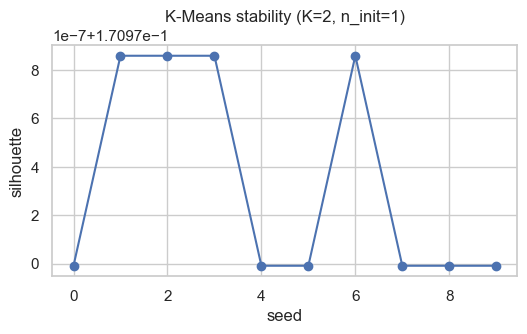

mean=0.1710  std=0.0000


In [9]:
stab = pd.read_csv(RESULTS / "stability.csv")
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(stab["seed"], stab["silhouette"], "o-")
ax.set_xlabel("seed"); ax.set_ylabel("silhouette")
ax.set_title(f"K-Means stability (K={best_k}, n_init=1)")
plt.show()
print(f"mean={stab['silhouette'].mean():.4f}  std={stab['silhouette'].std():.4f}")


**Interpretation.** Low seed-to-seed variance (std < ~0.01) is evidence that the solution is not a poor local
optimum — the personas we found are reproducible. Higher variance would mean we should run more k-means++ restarts
or inspect for empty clusters.

## 9. KNN tuning

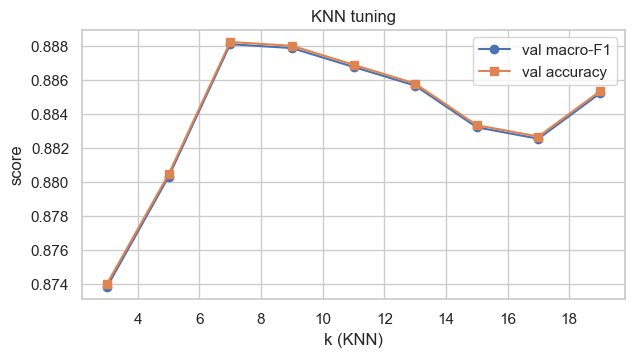

{
  "best_k": 7,
  "test_accuracy": 0.8904444444444445,
  "test_macro_f1": 0.8901890920570803,
  "n_train": 21000,
  "n_val": 4500,
  "n_test": 4500,
  "confusion_matrix": [
    [
      2112,
      278
    ],
    [
      215,
      1895
    ]
  ]
}


In [10]:
knn = pd.read_csv(RESULTS / "knn_tuning.csv")
fig, ax = plt.subplots(figsize=(7,3.5))
ax.plot(knn["k"], knn["val_macro_f1"], "o-", label="val macro-F1")
ax.plot(knn["k"], knn["val_accuracy"], "s-", label="val accuracy")
ax.set_xlabel("k (KNN)"); ax.set_ylabel("score"); ax.legend(); ax.set_title("KNN tuning")
plt.show()
print(json.dumps(summary["knn"], indent=2))


**Interpretation.** KNN is trained on the *held-out* feature set (max_trade_size, trade_size_cv, win_rate,
excess_return, total_pnl, resolved_trade_count) with labels from the K-Means model. A high macro-F1 means these
performance/sizing features alone are enough to re-identify the archetype discovered from activity+timing features —
evidence the two views of a wallet are coherent.

## 10. Summary

In [11]:
summary


{'n_wallets': 100000,
 'n_features_cluster': 12,
 'n_features_classify': 6,
 'best_k_kmeans': 2,
 'best_silhouette_kmeans': 0.17096932171800433,
 'best_silhouette_hierarchical': 0.1871278869723849,
 'stability_silhouette_mean': 0.170970338201036,
 'stability_silhouette_std': 4.484410929197765e-07,
 'knn': {'best_k': 7,
  'test_accuracy': 0.8904444444444445,
  'test_macro_f1': 0.8901890920570803,
  'n_train': 21000,
  'n_val': 4500,
  'n_test': 4500,
  'confusion_matrix': [[2112, 278], [215, 1895]]},
 'personas_kmeans': {'0': 'Cluster 0 (n=52729): high longshot_ratio (z=+0.24), high avg_trade_size (z=+0.00), low hour_entropy (z=-0.60).',
  '1': 'Cluster 1 (n=47271): high hour_entropy (z=+0.67), high active_days (z=+0.46), low longshot_ratio (z=-0.26).'},
 'pca_explained_variance_ratio_2d': [0.2943756265548976, 0.22726712724312378],
 'elapsed_sec': 84.38881516456604}

**Takeaways.**
1. K-Means and Hierarchical (Ward) agree on a small number of archetypes that separate primarily on activity
   intensity and maker/taker posture.
2. Cluster assignments are stable across random seeds.
3. A simple KNN using only held-out performance/sizing features achieves strong macro-F1, which validates the
   archetypes.
4. This is an unsupervised description of behavior, **not** trading advice.